
    CRIM - per capita crime rate by town
    ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
    INDUS - proportion of non-retail business acres per town.
    CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
    NOX - nitric oxides concentration (parts per 10 million)
    RM - average number of rooms per dwelling
    AGE - proportion of owner-occupied units built prior to 1940
    DIS - weighted distances to five Boston employment centres
    RAD - index of accessibility to radial highways
    TAX - full-value property-tax rate per $10,000
    PTRATIO - pupil-teacher ratio by town
    B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
    LSTAT - % lower status of the population
    MEDV - Median value of owner-occupied homes in $1000's


## Begin

In [33]:
import pandas as pd
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import  mean_squared_error, r2_score, mean_absolute_error, accuracy_score, confusion_matrix, RocCurveDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import AdaBoostRegressor, AdaBoostClassifier
import umap

In [2]:
Columns=['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']
data = pd.read_csv('bostonh.dat', names=Columns ,header=None, delim_whitespace=True)
data.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_2976\986677657.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv('bostonh.dat', names=Columns ,header=None, delim_whitespace=True)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    float64
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [4]:
data['chas'].value_counts()

chas
0    471
1     35
Name: count, dtype: int64

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
crim,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
zn,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
indus,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
chas,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
nox,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
rm,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
age,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
dis,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
rad,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
tax,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [6]:
data.shape

(506, 14)

## Correlation matrix

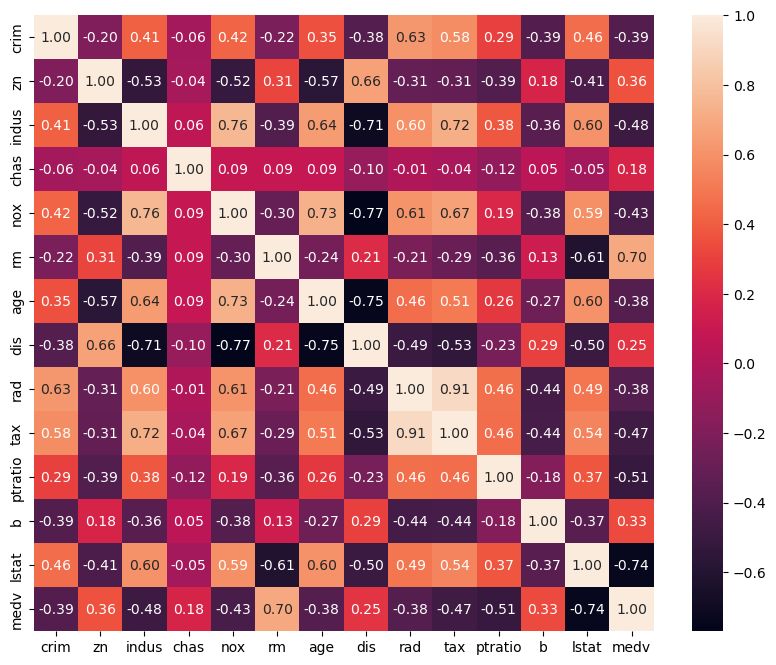

In [7]:
corr_matrix = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.show()

## Histplot

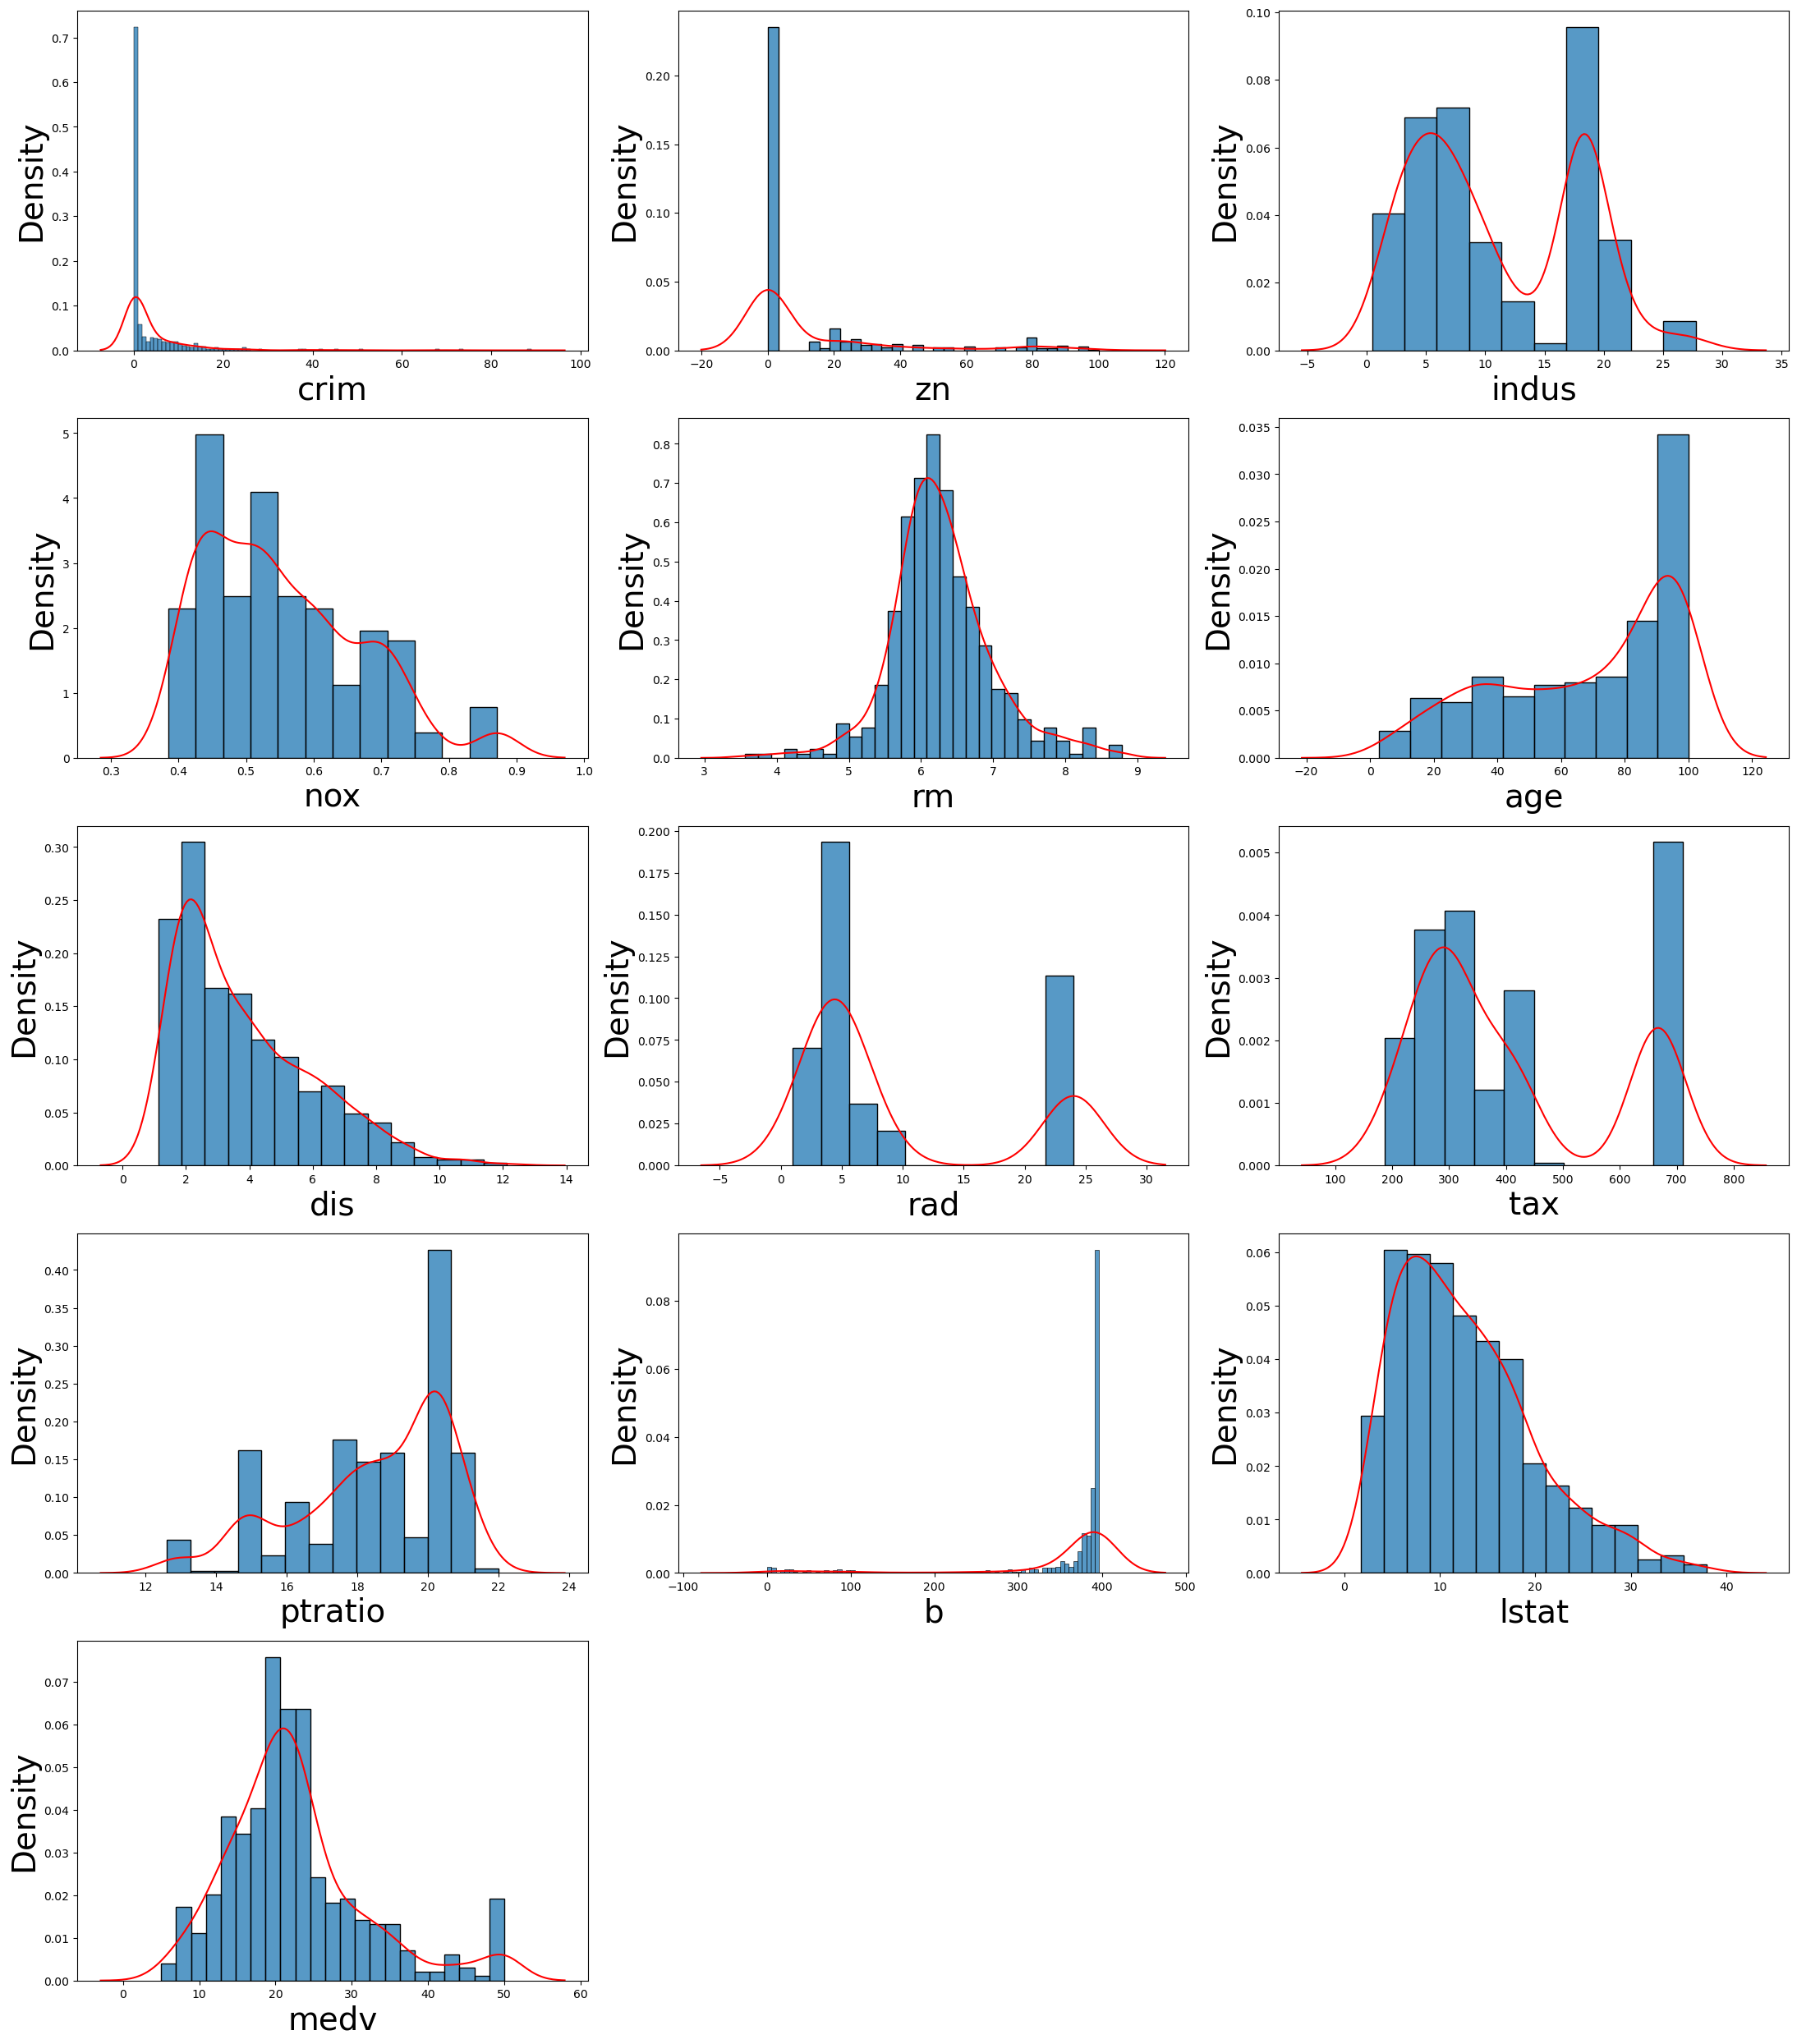

In [8]:
fig, ax = plt.subplots(5, 3, figsize=(22 ,25))
ax = ax.flatten()
for i, col in enumerate(data.drop(columns='chas').columns):
    sns.histplot(data=data[col], ax=ax[i], kde=False, stat='density')
    sns.kdeplot(data=data[col], ax=ax[i], color='r')
    ax[i].set_xlabel(col, fontsize=28)
    ax[i].set_ylabel('Density', fontsize=28)


for j in range(i+1, len(ax)):
    ax[j].axis('off')

plt.tight_layout()
clear_output()

plt.show()

## Pairplot

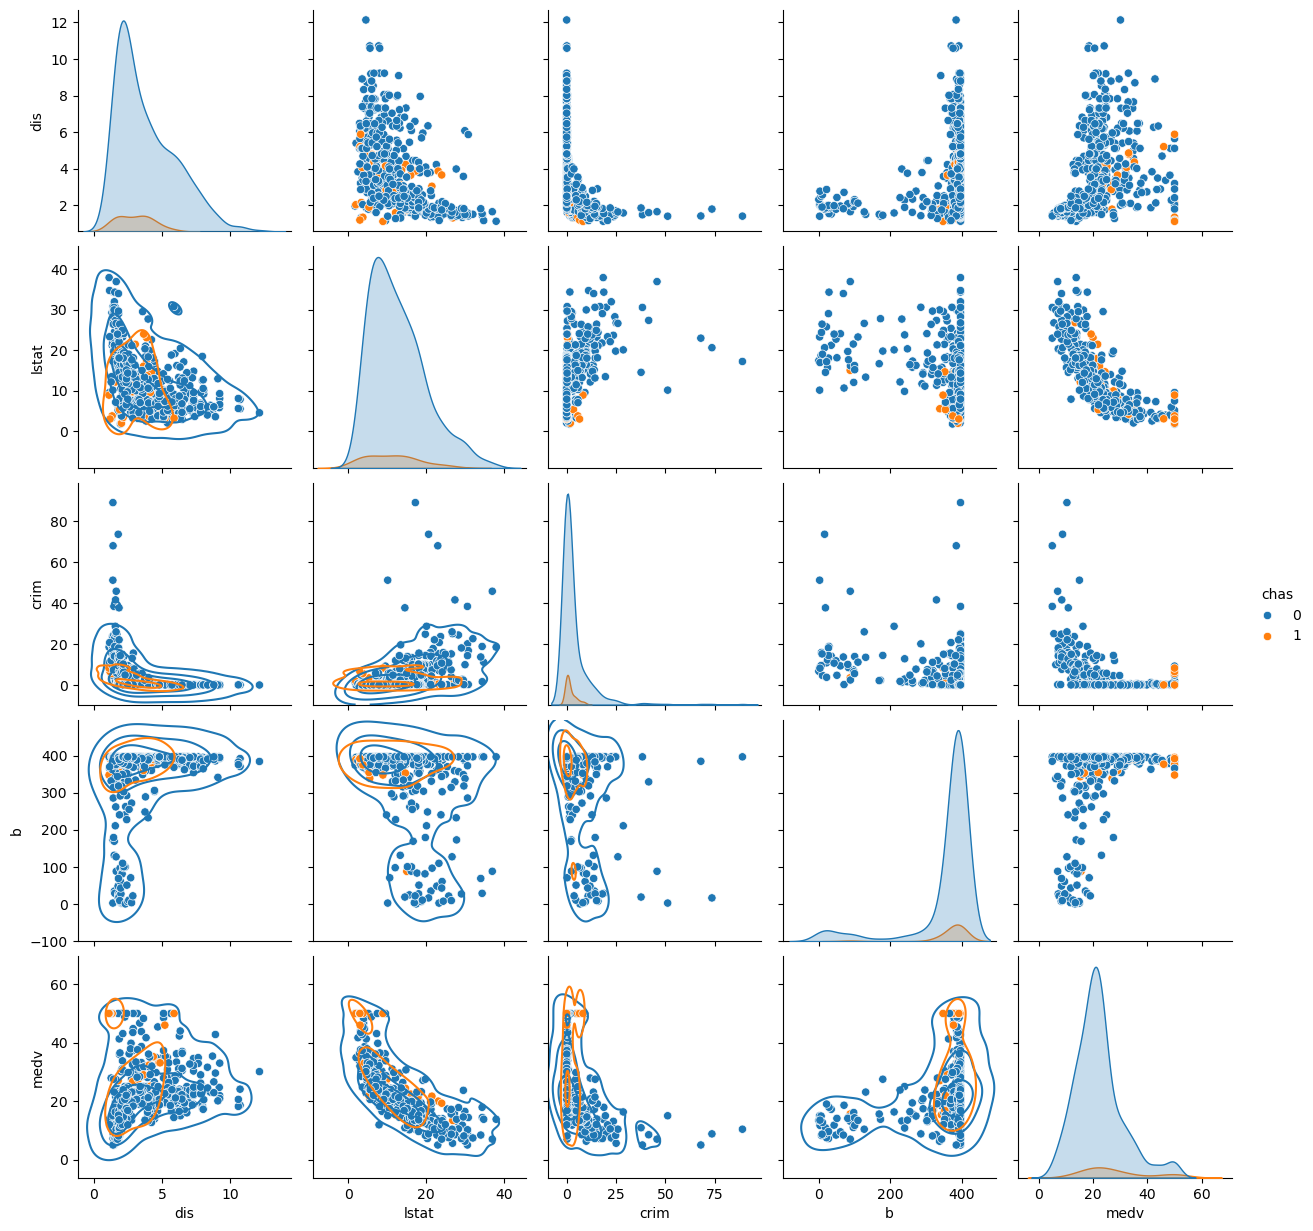

In [9]:
pic = sns.pairplot(data, vars=['dis', 'lstat', 'crim', 'b', 'medv'], hue="chas")
pic.map_lower(sns.kdeplot, levels=4, color=".2")
clear_output()
plt.show()

## Delete 'chas'

In [10]:
data = data[data['chas'] != 1].reset_index(drop=True).drop(columns='chas')

In [11]:
data

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,0.06263,0.0,11.93,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
467,0.04527,0.0,11.93,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
468,0.06076,0.0,11.93,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
469,0.10959,0.0,11.93,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


---

# PCA

In [12]:
def label_medv(val):
    if val < 18:
        return 'Low'
    elif val < 25:
        return 'Medium'
    else:
        return 'High'

data['medv_level'] = data['medv'].apply(label_medv)

In [13]:
data['medv_level'].value_counts()

medv_level
Medium    213
Low       142
High      116
Name: count, dtype: int64

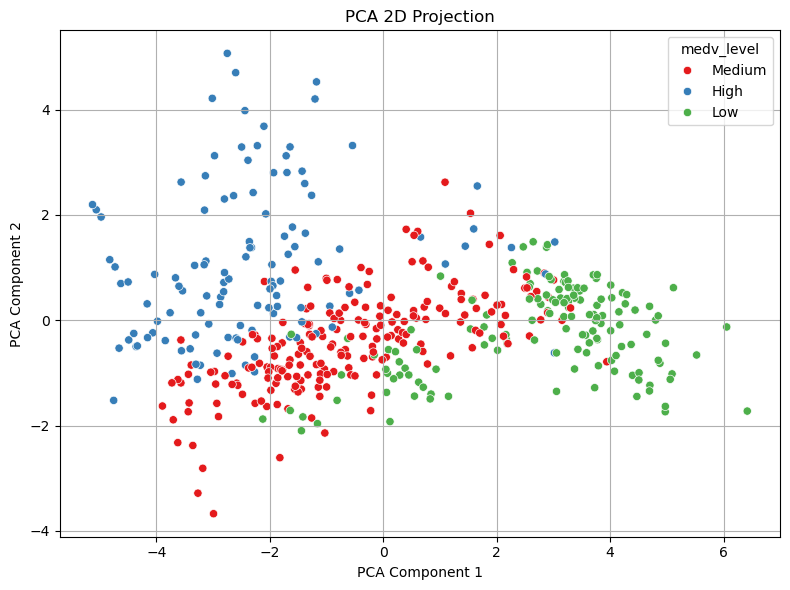

In [14]:
scaler = StandardScaler()

data_sclaed = scaler.fit_transform(data.drop(columns='medv_level'))
pca = PCA(n_components=2, random_state=42)
data_pca = pca.fit_transform(data_sclaed)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=data['medv_level'], palette='Set1')
plt.title("PCA 2D Projection")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

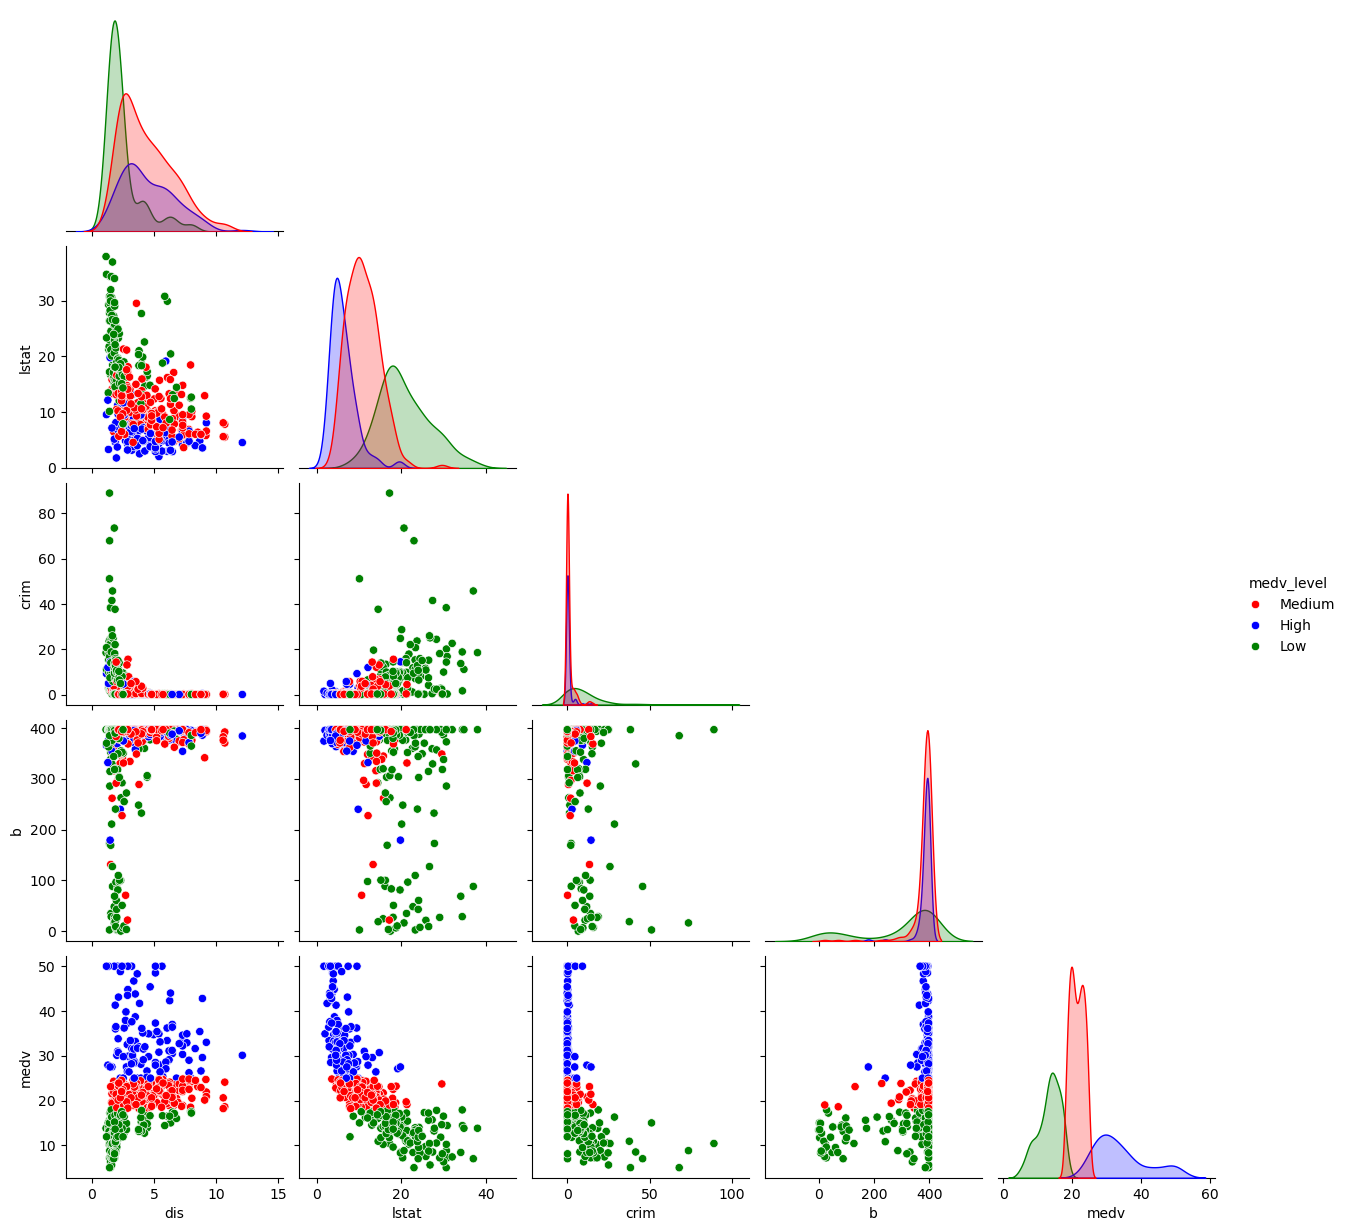

In [15]:
sns.pairplot(data=data, vars=['dis', 'lstat', 'crim', 'b', 'medv'], hue='medv_level',palette={'Low': 'green', 'High': 'blue', 'Medium': 'red'},
            diag_kind='kde', corner=True)
clear_output()
plt.show()

---

# UMAP

In [16]:
# umap_=umap.UMAP(random_state=42)
# data_ump = umap_.fit_transform(data_sclaed)

In [17]:
# data_ump.shape

In [18]:
# sns.scatterplot(
#     x=data_ump[:, 0],
#     y=data_ump[:, 1],
#     hue=data['medv_level'], palette='Set1')
# # plt.gca().set_aspect('equal', 'datalim')
# plt.title('UMAP', fontsize=24)

---

# Linear Regression

In [19]:
X = data.drop(columns=['medv', 'medv_level'])
y = data['medv']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.shape

(329, 12)

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
X_train_constant = sm.add_constant(X_train_scaled)
X_test_consatnt = sm.add_constant(X_test_scaled)
model = sm.OLS(y_train, X_train_constant).fit()
y_pred = model.predict(X_test_consatnt)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R² Score: {r2:.4f}')

MSE: 17.48
MAE: 2.82
R² Score: 0.7598


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     77.22
Date:                Thu, 10 Apr 2025   Prob (F-statistic):           2.33e-86
Time:                        00:03:45   Log-Likelihood:                -962.46
No. Observations:                 329   AIC:                             1951.
Df Residuals:                     316   BIC:                             2000.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.0657      0.254     86.959      0.0

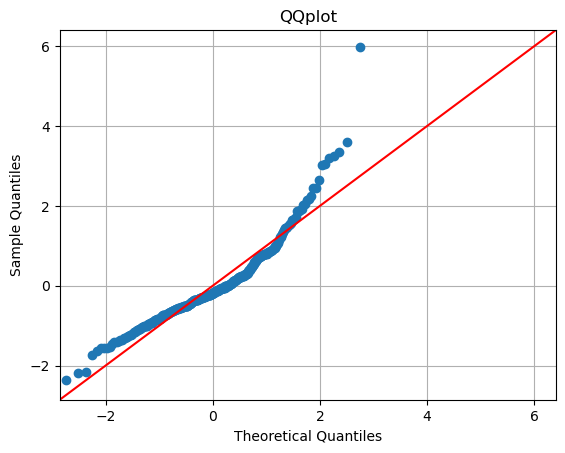

In [22]:
print(model.summary())
residuals = model.resid
sm.qqplot(residuals, line='45', fit=True)
plt.title("QQplot")
plt.grid(True)
plt.show()

---

# Adaboost regressor

In [23]:
X = data.drop(columns=['medv', 'medv_level'])
y = data['medv']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

abr = AdaBoostRegressor(random_state=42)
model = abr.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R² Score: {r2:.4f}')

MSE: 14.41
MAE: 2.63
R² Score: 0.8020


---

# Adaboost classifier

In [24]:
X = data.drop(columns=['medv', 'medv_level'])
y = data['medv_level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

abr = AdaBoostClassifier(random_state=42)
model = abr.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f'accuracy_score: {accuracy_score(y_test, y_pred)}')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


accuracy_score: 0.823943661971831
[[27  0  5]
 [ 0 27 11]
 [ 4  5 63]]
              precision    recall  f1-score   support

        High       0.87      0.84      0.86        32
         Low       0.84      0.71      0.77        38
      Medium       0.80      0.88      0.83        72

    accuracy                           0.82       142
   macro avg       0.84      0.81      0.82       142
weighted avg       0.83      0.82      0.82       142



c:\Users\USER\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [28]:
data['crim']=np.log(data['crim'])
data['zn']=data['zn']/10
data['indus']=np.log(data['indus'])
data['nox']=np.log(data['nox'])
data['rm']=np.log(data['rm'])
data['age']=data['age']**2/10000
data['dis']=np.log(data['dis'])
data['rad']=np.log(data['rad'])
data['tax']=np.log(data['tax'])
data['ptratio']=np.exp(0.4*data['ptratio'])/1000
data['b']=np.log(data['b'])
data['lstat']=np.sqrt(data['lstat'])
data['medv']=np.log(data['medv'])

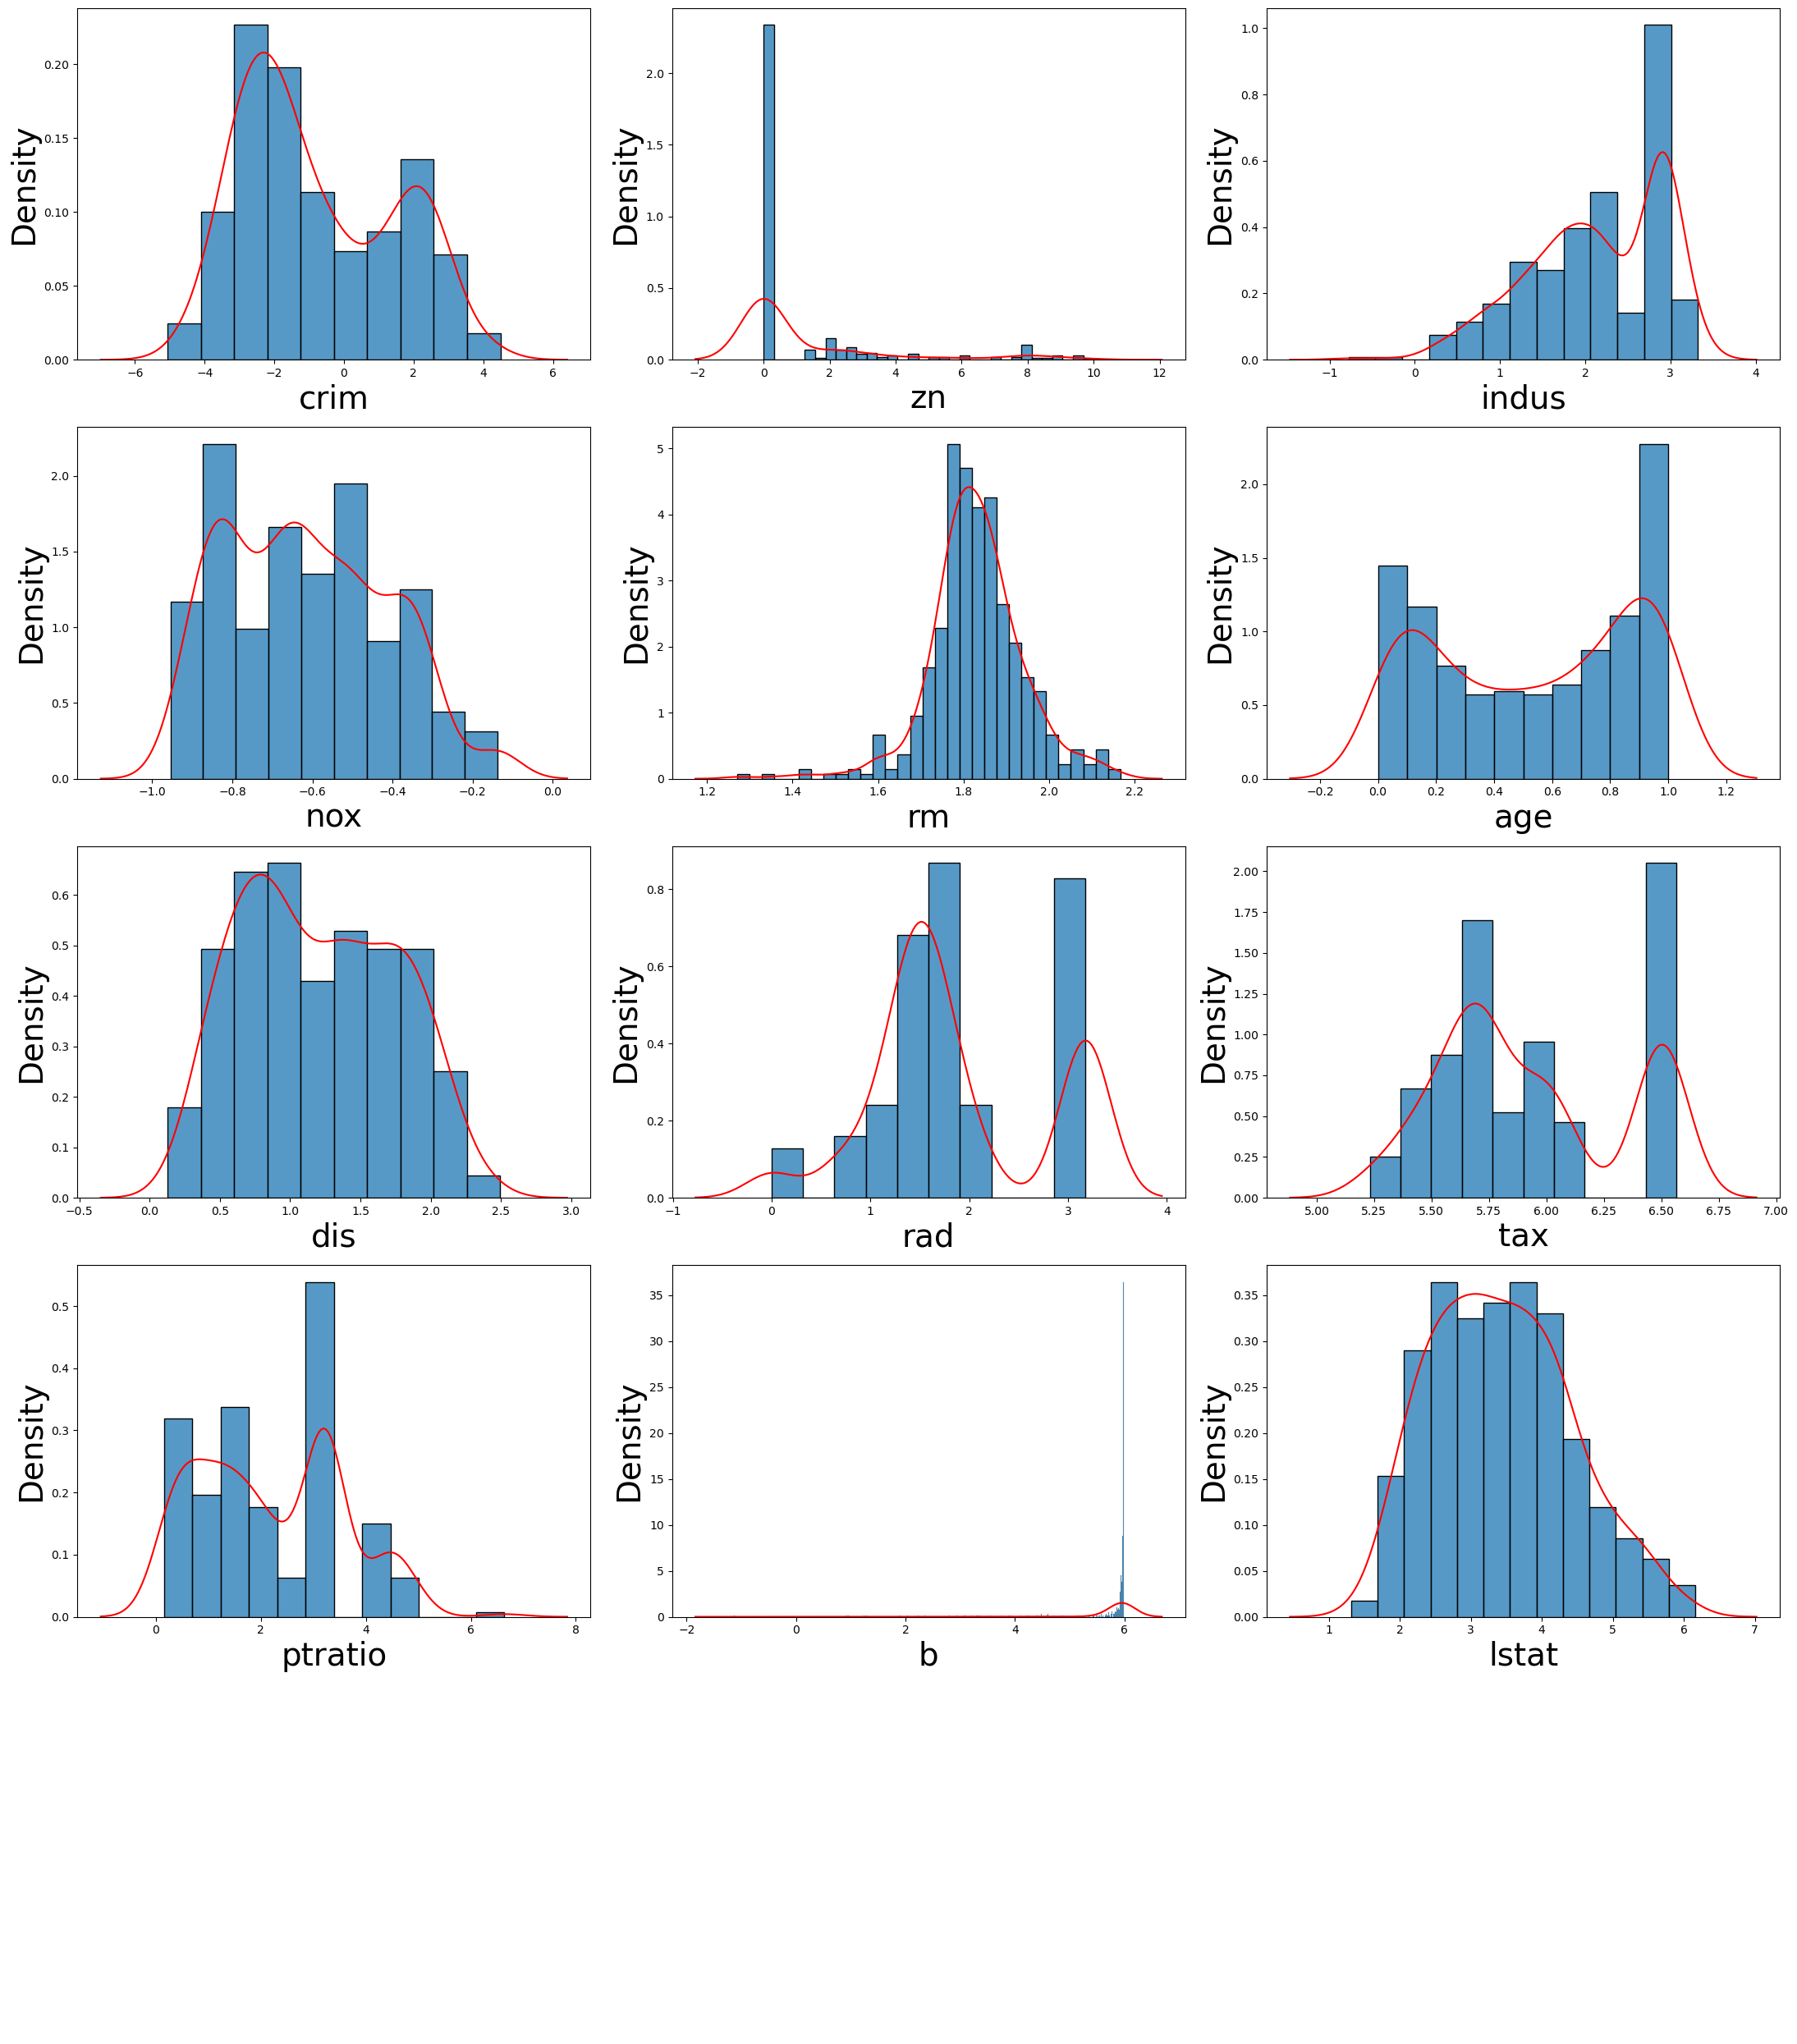

In [30]:
fig, ax = plt.subplots(5, 3, figsize=(22 ,25))
ax = ax.flatten()
for i, col in enumerate(data.drop(columns=['medv', 'medv_level']).columns):
    sns.histplot(data=data[col], ax=ax[i], kde=False, stat='density')
    sns.kdeplot(data=data[col], ax=ax[i], color='r')
    ax[i].set_xlabel(col, fontsize=28)
    ax[i].set_ylabel('Density', fontsize=28)


for j in range(i+1, len(ax)):
    ax[j].axis('off')

plt.tight_layout()
clear_output()

plt.show()

In [34]:
X = data.drop(columns=['medv', 'medv_level'])
y = data['medv']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

lr = LinearRegression()
model = lr.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R² Score: {r2:.4f}')


MSE: 0.03
MAE: 0.12
R² Score: 0.8331


In [35]:
X_train_constant = sm.add_constant(X_train_scaled)
X_test_consatnt = sm.add_constant(X_test_scaled)

model = sm.OLS(y_train, X_train_constant).fit()
y_pred = model.predict(X_test_consatnt)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R² Score: {r2:.4f}')

MSE: 0.03
MAE: 0.12
R² Score: 0.8331


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     73.30
Date:                Thu, 10 Apr 2025   Prob (F-statistic):           9.67e-84
Time:                        00:07:28   Log-Likelihood:                 44.476
No. Observations:                 329   AIC:                            -62.95
Df Residuals:                     316   BIC:                            -13.60
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0132      0.012    253.408      0.0

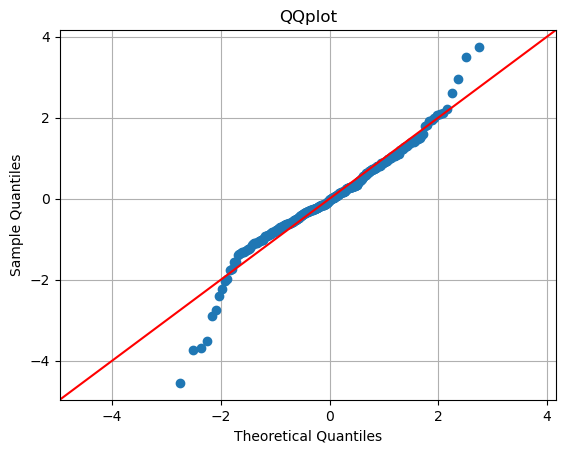

In [36]:
print(model.summary())
residuals = model.resid
sm.qqplot(residuals, line='45', fit=True)
plt.title("QQplot")
plt.grid(True)
plt.show()